In [1]:
import os

import numpy as np
import pandas as pd

raw_data_dir = "/home/youngjins/project/belief_trading/data/binance/futures/um/monthly/aggTrades/BTCUSDT/"

# 데이터 파일 목록 가져오기
data_files = [f for f in os.listdir(raw_data_dir) if f.endswith(".csv")]

# 데이터 파일 목록을 날짜 순으로 정렬
data_files.sort()

data_files

['BTCUSDT-aggTrades-2022-04.csv',
 'BTCUSDT-aggTrades-2022-05.csv',
 'BTCUSDT-aggTrades-2022-06.csv',
 'BTCUSDT-aggTrades-2022-07.csv',
 'BTCUSDT-aggTrades-2022-08.csv',
 'BTCUSDT-aggTrades-2022-09.csv',
 'BTCUSDT-aggTrades-2022-10.csv',
 'BTCUSDT-aggTrades-2022-11.csv',
 'BTCUSDT-aggTrades-2022-12.csv',
 'BTCUSDT-aggTrades-2023-01.csv',
 'BTCUSDT-aggTrades-2023-02.csv',
 'BTCUSDT-aggTrades-2023-03.csv',
 'BTCUSDT-aggTrades-2023-04.csv',
 'BTCUSDT-aggTrades-2023-05.csv',
 'BTCUSDT-aggTrades-2023-06.csv',
 'BTCUSDT-aggTrades-2023-07.csv',
 'BTCUSDT-aggTrades-2023-08.csv',
 'BTCUSDT-aggTrades-2023-09.csv',
 'BTCUSDT-aggTrades-2023-10.csv',
 'BTCUSDT-aggTrades-2023-11.csv',
 'BTCUSDT-aggTrades-2023-12.csv',
 'BTCUSDT-aggTrades-2024-01.csv',
 'BTCUSDT-aggTrades-2024-02.csv',
 'BTCUSDT-aggTrades-2024-03.csv',
 'BTCUSDT-aggTrades-2024-04.csv',
 'BTCUSDT-aggTrades-2024-05.csv',
 'BTCUSDT-aggTrades-2024-06.csv',
 'BTCUSDT-aggTrades-2024-07.csv',
 'BTCUSDT-aggTrades-2024-08.csv',
 'BTCUSDT-aggT

In [2]:
# data_files의 데이터 전처리 계획:
# 1. 시간 윈도우: 1시간(1h) 단위로 거래 데이터를 그룹화
# 2. 트레이더 분류: 거래량(quantity) * 가격 (price) 기준으로 상위 20%는 기관 투자자, 나머지 80%는 개인 투자자로 분류
# 3. 거래 방향 정의: 'is_buyer_maker' 필드가 false인 경우 매수(long), true인 경우 매도(short)로 분류
# 4. 집계 방법: 각 시간 윈도우 내에서 트레이더 유형별(개인/기관)로 매수/매도 행동 분포를 계산하여 하나의 데이터 포인트로 생성

# window_size
window_size = 1 * 60 * 60 * 1000  # 1시간(1h)을 밀리초로 변환
type_threshold = 0.2
usecols = [
    "price",
    "quantity",
    "transact_time",
    "is_buyer_maker",
]
for file in data_files:
    df = pd.read_csv(
        os.path.join(raw_data_dir, file),
        index_col=0,
        usecols=usecols,
        nrows=10000000,
    ).reset_index()
    df.loc[:, "transact_time"] = pd.to_datetime(df.loc[:, "transact_time"], unit="ms")

    # 시간 윈도우 설정

    break

In [3]:
# df를 1시간 단위로 그룹화 - 1시간 내에 발생한 것 중에서 거래량 * 가격으로 개인/기관으로 분류 후, long/short 행동 분포를 list로 분류
df.loc[:, "quantity_price"] = df.loc[:, "quantity"] * df.loc[:, "price"]

# 결과 데이터 프레임 생성
# - index: df.index를 1시간 단위로 그룹화한 것
# - columns: retail_long, retail_short, institutional_long, institutional_short
result_start = (df.iloc[0]["transact_time"] + pd.Timedelta(hours=1)).strftime(
    "%Y-%m-%d %H"
)
result_end = (df.iloc[-1]["transact_time"] + pd.Timedelta(hours=1)).strftime(
    "%Y-%m-%d %H"
)

result_df = pd.DataFrame(
    index=pd.date_range(
        start=result_start,
        end=result_end,
        freq=f"{window_size}ms",
    ),
    columns=[
        "retail_long",
        "retail_short",
        "institutional_long",
        "institutional_short",
    ],
)

# df의 한시간 단위로 for loop 돌리기
quantile = 50
quantile_bins = np.linspace(-1, 1, 2 * quantile + 1)
for pivot_time in result_df.index:

    df_subset = df.loc[
        (df.loc[:, "transact_time"] < pivot_time)
        & (df.loc[:, "transact_time"] >= pivot_time - pd.Timedelta(hours=1))
    ]

    if df_subset.empty:
        continue

    # df_subset을 is_buyer_maker 기준으로 long, short 값으로 분류
    # long: is_buyer_maker == False
    # short: is_buyer_maker == True
    long_df = df_subset[df_subset["is_buyer_maker"] == False].loc[:, "quantity_price"]
    short_df = (-1) * df_subset[df_subset["is_buyer_maker"] == True].loc[
        :, "quantity_price"
    ]

    # long_df, short_df를 합친 후, 거래량 * 가격 기준으로 정렬
    quantity_price_df = pd.concat([long_df, short_df]).sort_values(ascending=False)

    # -1 ~ 1 사이의 값으로 정규화
    quantity_price_df = quantity_price_df / quantity_price_df.abs().max()

    # long에 해당하는 +값 중에서 상위 20%는 기관, 나머지 80%는 개인으로 분류
    qp_long_df = quantity_price_df.loc[quantity_price_df >= 0]
    long_type_threshold = int(len(qp_long_df) * type_threshold)
    institutional_long_df = qp_long_df.iloc[:long_type_threshold]
    retail_long_df = qp_long_df.iloc[long_type_threshold:]

    # short에 해당하는 -값 중에서 하위 20%는 기관, 나머지 80%는 개인으로 분류
    qp_short_df = quantity_price_df.loc[quantity_price_df < 0]
    short_type_shreshold = int(len(qp_short_df) * type_threshold)
    institutional_short_df = qp_short_df.iloc[short_type_shreshold:]
    retail_short_df = qp_short_df.iloc[:short_type_shreshold]

    # quantile_bins의 각 구간에 해당하는 값들을 카운트
    # 카운트 결과를 result_df에 저장
    retail_long_count = np.zeros(quantile)
    retail_short_count = np.zeros(quantile)
    institutional_long_count = np.zeros(quantile)
    institutional_short_count = np.zeros(quantile)
    for i in range(len(quantile_bins) - 1):
        if quantile_bins[i] < 0:
            retail_short_count[i] += len(
                retail_short_df.loc[
                    (quantile_bins[i] <= retail_short_df)
                    & (quantile_bins[i + 1] >= retail_short_df)
                ]
            )
            institutional_short_count[i] += len(
                institutional_short_df.loc[
                    (quantile_bins[i] <= institutional_short_df)
                    & (quantile_bins[i + 1] >= institutional_short_df)
                ]
            )
        else:
            retail_long_count[i - quantile] += len(retail_long_df.loc[
                (quantile_bins[i] <= retail_long_df)
                & (quantile_bins[i + 1] >= retail_long_df)
            ])
            institutional_long_count[i - quantile] += len(institutional_long_df.loc[
                (quantile_bins[i] <= institutional_long_df)
                & (quantile_bins[i + 1] >= institutional_long_df)
            ])
    
    # 개인/기관별 long, short 행동 분포의 넓이가 1이 되도록 정규화
    # retail_long_count = retail_long_count / retail_long_count.sum()
    # retail_short_count = retail_short_count / retail_short_count.sum()
    # institutional_long_count = institutional_long_count / institutional_long_count.sum()
    # institutional_short_count = institutional_short_count / institutional_short_count.sum()
    
    result_df.loc[pivot_time, "retail_long"] = retail_long_count
    result_df.loc[pivot_time, "retail_short"] = retail_short_count
    result_df.loc[pivot_time, "institutional_long"] = institutional_long_count
    result_df.loc[pivot_time, "institutional_short"] = institutional_short_count

/tmp/ipykernel_24480/1837252916.py:68: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


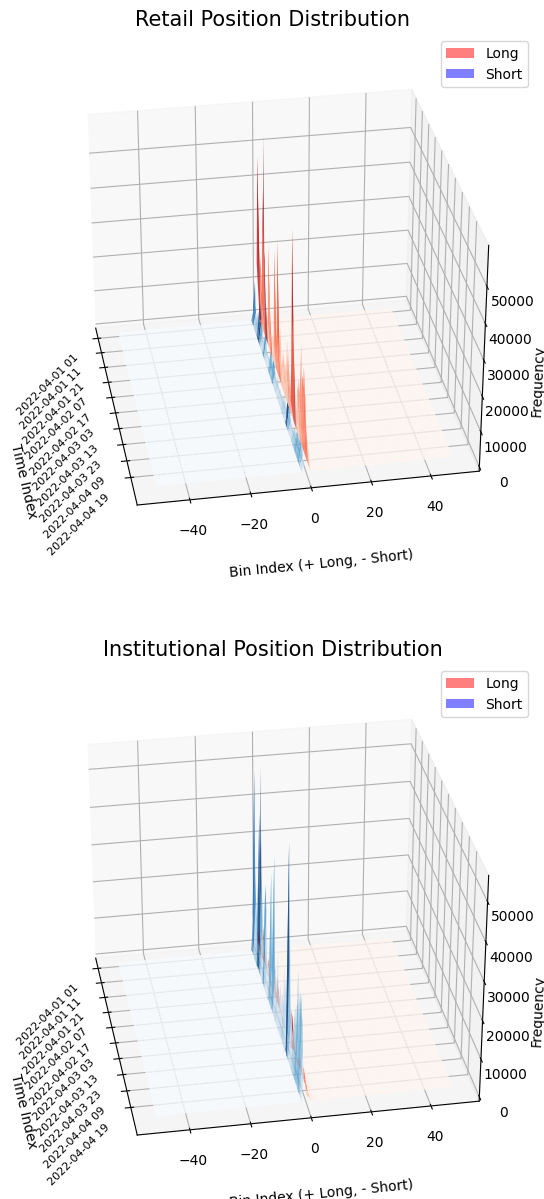

In [5]:
# result_df의 5행까지 3-d 분포 시각화 (x축: 시간, y축:bin수, z축: 값)
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 시각화할 행 수 제한
rows_to_plot = 100
data_to_plot = result_df.iloc[:rows_to_plot]

# 개인과 기관별로 그래프 생성 (각각 long/short을 한 그래프에 표시)
fig = plt.figure(figsize=(20, 15))

# 개인(retail)과 기관(institutional) 그래프 생성
categories = ['retail', 'institutional']
num_time_index = 10
for idx, category in enumerate(categories):
    ax = fig.add_subplot(2, 1, idx+1, projection='3d')
    
    # 데이터 준비
    x_times = np.arange(len(data_to_plot))
    
    # long과 short 데이터를 하나의 그래프에 표시하기 위해 bin 인덱스 조정
    # short은 음수 bin으로, long은 양수 bin으로 표시
    long_bins = np.arange(len(data_to_plot.iloc[0][f"{category}_long"]))
    # short_bins 순서 변경: 가장 작은 음수가 0에 가깝게 배치
    short_bins = -np.arange(len(data_to_plot.iloc[0][f"{category}_short"]))[::-1] - 1
    
    # Long 데이터 처리
    X_long, Y_long = np.meshgrid(x_times, long_bins)
    Z_long = np.zeros((len(long_bins), len(x_times)))
    for i, time_idx in enumerate(x_times):
        Z_long[:, i] = data_to_plot.iloc[i][f"{category}_long"]
    
    # Short 데이터 처리
    X_short, Y_short = np.meshgrid(x_times, short_bins)
    Z_short = np.zeros((len(short_bins), len(x_times)))
    for i, time_idx in enumerate(x_times):
        Z_short[:, i] = data_to_plot.iloc[i][f"{category}_short"]
    
    # 3D 표면 그래프 그리기
    surf_long = ax.plot_surface(X_long, Y_long, Z_long, cmap='Reds', edgecolor='none', alpha=0.8, label='Long')
    surf_short = ax.plot_surface(X_short, Y_short, Z_short, cmap='Blues', edgecolor='none', alpha=0.8, label='Short')
    
    # 그래프 제목 및 레이블 설정
    ax.set_title(f'{category.capitalize()} Position Distribution', fontsize=15)
    ax.set_xlabel('Time Index', labelpad=35)  # labelpad 값을 증가시켜 라벨을 뒤로 이동
    ax.set_ylabel('Bin Index (+ Long, - Short)', labelpad=15)
    ax.set_zlabel('Frequency')
    
    # 실제 시간 표시를 위한 눈금 설정
    time_labels = [str(t)[:13] for t in data_to_plot.index]
    # rows_to_plot에 따라 적절한 간격으로 눈금 설정
    tick_interval = max(1, len(x_times) // 10)  # 최대 10개의 눈금만 표시
    selected_ticks = x_times[::tick_interval]
    selected_labels = [time_labels[i] for i in selected_ticks]
    ax.set_xticks(selected_ticks)
    ax.set_xticklabels(selected_labels, rotation=45, ha='right', fontsize=8)
    
    # x축 라벨이 더 잘 보이도록 뷰 각도 조정
    ax.view_init(elev=30, azim=-10)
    
    # 범례 추가 (3D 그래프에서는 직접 범례를 추가하기 어려워 별도 처리)
    # 더미 객체로 범례 생성
    long_proxy = plt.Rectangle((0, 0), 1, 1, fc="red", alpha=0.5)
    short_proxy = plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.5)
    ax.legend([long_proxy, short_proxy], ['Long', 'Short'], loc='upper right')

plt.tight_layout()
plt.show()


In [6]:
result_df


,retail_long,retail_short,institutional_long,institutional_short
2022-04-01 01:00:00,"[17142.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4213.0, 57.0, 7.0, 3.0, 1.0, 2.0, 0.0, 0.0, 0...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2022-04-01 02:00:00,"[31276.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7629.0, 138.0, 34.0, 6.0, 3.0, 2.0, 2.0, 0.0,...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2022-04-01 03:00:00,"[48564.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[11824.0, 236.0, 43.0, 17.0, 6.0, 4.0, 2.0, 1....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2022-04-01 04:00:00,"[24625.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[5540.0, 395.0, 128.0, 37.0, 16.0, 12.0, 5.0, ...","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ..."
2022-04-01 05:00:00,"[18379.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3946.0, 406.0, 141.0, 38.0, 18.0, 17.0, 7.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...
2022-04-10 09:00:00,"[8072.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1364.0, 400.0, 116.0, 42.0, 26.0, 17.0, 13.0,...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ..."
2022-04-10 10:00:00,"[9590.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1132.0, 685.0, 250.0, 117.0, 50.0, 53.0, 23.0...","[0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, ..."
2022-04-10 11:00:00,"[8867.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1524.0, 408.0, 106.0, 73.0, 23.0, 19.0, 14.0,...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2022-04-10 12:00:00,"[10104.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1271.0, 645.0, 261.0, 112.0, 79.0, 36.0, 29.0...","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ..."
